[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke01-introduksjon/00-velkommen.ipynb)

## 📓 00-velkommen.ipynb

# 🎉 Velkommen til AI og Helse!

## Om dette kurset

Dette er et åpent kurs som gir deg praktisk kompetanse i kunstig intelligens 
for helse- og omsorgssektoren. Kurset går over 8 <strike>10</strike> uker og kombinerer teori med 
hands-on erfaring.

**"... på svømmekurs må man oppholde seg mye i bassenget ..."**

### Hvem er jeg?
Jeg har etablert dette åpne kurset, og arbeidet med medisinsk bildebehandling siden 1987 og AI i helsevesenet/universitetet i over 10 år [[Google Scholar](https://scholar.google.com/citations?user=HqmyBUUAAAAJ&hl=en)].<br>
Min bakgrunn inkluderer både litt klinisk erfaring, litt teknisk kompetanse og litt undervisning- og forskningskompetanse.

### Hvem er dere?
La oss bli kjent! Kjør cellen nedenfor og fyll inn din info.

### Men først: 🔧 miljøoppsett - kode skal fungere både lokalt og i Google Colab

In [1]:
import sys
import subprocess
import os

# Sjekk om vi kjører i Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    
    # Installer nødvendige pakker som ikke er forhåndsinstallert i Colab
    !pip install seaborn --quiet
    
    # Sjekk om mappen allerede eksisterer
    if not os.path.exists('AI-og-helse'):
        print("📥 Laster ned kursmateriell...")
        try:
            # Prøv å klone repositoryet (da være public)
            #!git clone https://github.com/arvidl/AI-og-helse.git
            print("✅ Repository klonet vellykket!")
        except:
            print("⚠️ Kunne ikke klone repository automatisk")
            print("💡 Du kan laste opp filer manuelt eller bruke en annen metode")
    
    # Bytt til riktig mappe hvis den eksisterer
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
    else:
        print("📂 Arbeider i standard Colab-mappe")
        
else:
    print("💻 Kjører i lokal miljø")

# Standard imports som fungerer overalt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Miljø er konfigurert og klart!")

💻 Kjører i lokal miljø
✅ Miljø er konfigurert og klart!


In [2]:
# Interaktiv introduksjon
from datetime import datetime
import json

def introduser_deg():
    """La oss bli kjent!"""
    print("🤝 Velkommen! La oss bli kjent.")
    print("-" * 40)
    
    # Samle informasjon
    info = {}
    info['navn'] = input("Hva heter du? ")
    info['yrke'] = input("Hva jobber du med? ")
    info['erfaring_ai'] = input("Har du erfaring med AI? (ja/nei/litt) ")
    info['motivasjon'] = input("Hvorfor tar du dette kurset? ")
    info['dato'] = datetime.now().strftime("%Y-%m-%d")
    
    # Lagre til fil (valgfritt)
    if IN_COLAB:
        intro_fil = 'min_introduksjon.json'
    else:
        intro_fil = './ressurser/min_introduksjon.json'
    with open(intro_fil, 'w') as f:
            json.dump(info, f, indent=2, ensure_ascii=False)
    
    print("\n✅ Flott! Du er nå registrert i kurset.")
    print(f"👋 Velkommen, {info['navn']}!")
    
    # Gi tilpasset velkomst
    if 'nei' in info['erfaring_ai'].lower():
        print("💡 Ingen bekymring - vi starter helt fra bunnen!")
    elif 'litt' in info['erfaring_ai'].lower():
        print("💡 Perfekt! Du har et godt utgangspunkt.")
    else:
        print("💡 Supert! Din erfaring vil berike diskusjonene.")
    
    return info

In [3]:
# Kjør introduksjonen
min_info = introduser_deg()


🤝 Velkommen! La oss bli kjent.
----------------------------------------

✅ Flott! Du er nå registrert i kurset.
👋 Velkommen, erik!
💡 Perfekt! Du har et godt utgangspunkt.


In [4]:
min_info

{'navn': 'erik',
 'yrke': 'sykeleier',
 'erfaring_ai': 'litt',
 'motivasjon': 'lære mer',
 'dato': '2025-10-27'}

## Kursstruktur

### 📅 8 ukers reise

| Uke | Tema | Fokus |
|-----|------|-------|
| 1-3 | **Grunnleggende AI** | Fra regelbaser til nevrale nettverk, maskinlæring (AI 1.0)|
| 4-6 | **Moderne AI** | Generativ AI, LLM, multimodal AI (AI 2.0) |
| 7-8 | **Anvendelser** / **Etikk** / **Regulering** | Velferdsteknologi; robotikk; etisk AI; CE, GDPR, MDR, EU AI Act |


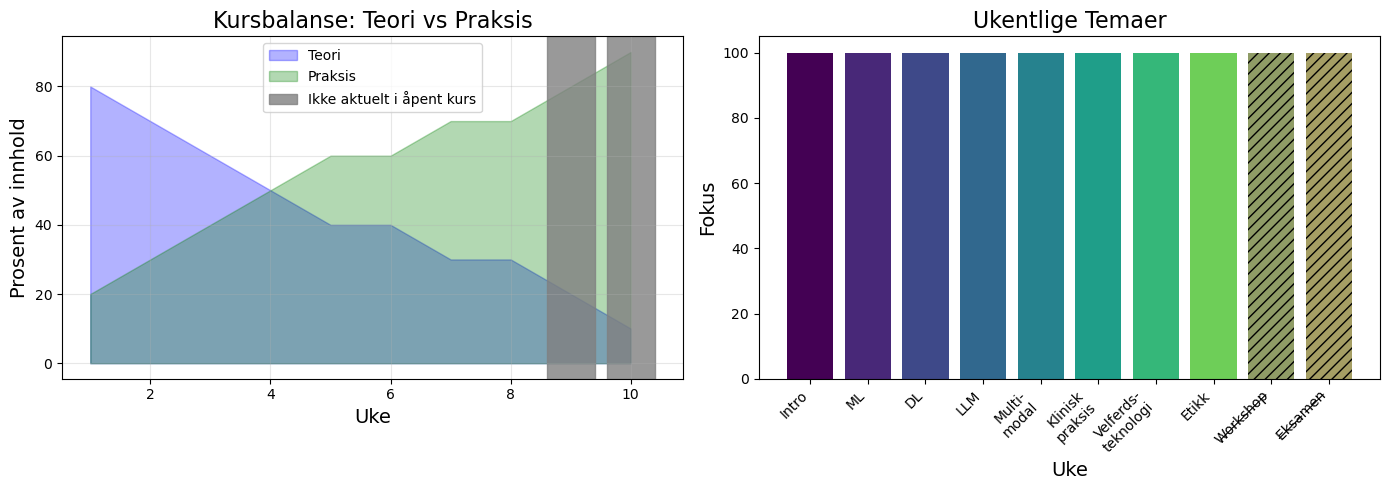

In [5]:
# Visualiser kursstrukturen
import matplotlib.pyplot as plt
import numpy as np

# Data for visualisering
uker = list(range(1, 11))
teori_prosent = [80, 70, 60, 50, 40, 40, 30, 30, 20, 10]
praksis_prosent = [20, 30, 40, 50, 60, 60, 70, 70, 80, 90]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Teori vs Praksis
ax1.fill_between(uker, teori_prosent, alpha=0.3, label='Teori', color='blue')
ax1.fill_between(uker, praksis_prosent, alpha=0.3, label='Praksis', color='green')
ax1.set_xlabel('Uke', fontsize=14)
ax1.set_ylabel('Prosent av innhold', fontsize=14)
ax1.set_title('Kursbalanse: Teori vs Praksis', fontsize=16)
ax1.grid(True, alpha=0.3)

# Skraver uke 9-10 (ikke aktuelle uker i åpent krs)
for uke in [9, 10]:
    ax1.axvspan(uke-0.4, uke+0.4, alpha=0.8,  color='gray', 
               label='Ikke aktuelt i åpent kurs' if uke == 9 else "")
ax1.legend(fontsize=10)

# Unicode strikethrough characters
def strikethrough(text):
    """Legg til strikethrough til tekst"""
    return ''.join([char + '\u0336' for char in text])

# Temaer per uke
temaer = ['Intro', 'ML', 'DL', 'LLM', 'Multi-\nmodal', 'Klinisk\npraksis', 
          'Velferds-\nteknologi', 'Etikk', strikethrough("Workshop"), strikethrough("Eksamen")]
farger = plt.cm.viridis(np.linspace(0, 1, 10))

ax2.bar(uker, [100]*10, color=farger)
# Skraver uke 9-10 med hatching
for uke in [9, 10]:
    ax2.bar(uke, 100, color='gray', hatch='///', alpha=0.7)
ax2.set_xlabel('Uke', fontsize=14)
ax2.set_ylabel('Fokus', fontsize=14)
ax2.set_title('Ukentlige Temaer', fontsize=16)
ax2.set_xticks(uker)
ax2.set_xticklabels(temaer, rotation=45, ha='right', fontsize=10)


plt.tight_layout()
plt.show()

## 💻 Teknisk oppsett

### Hva trenger du?
1. **GitHub-konto** (gratis) - https://github.com [[get started](https://docs.github.com/en/get-started/start-your-journey/creating-an-account-on-github)]
2. **Nettleser** (Chrome, Firefox, Safari, Edge)
3. **API-nøkler** (for bruk av LLM-ressurser fra [OpenAI](https://platform.openai.com) og [Anthropic](https://console.anthropic.com), $$)
3. **Internett** (stabilt)

### Hva trenger du IKKE?
- ❌ Installere Python lokalt (men gjør det gjerne - [Anaconda](https://en.wikipedia.org/wiki/Anaconda_(Python_distribution)))
- ❌ Kraftig datamaskin
- ❌ Programmeringserfaring

Alt kan kjøres i skyen via Google Colaboratory ([Colab](https://en.wikipedia.org/wiki/Google_Colab))! (evt. [GitHub Codespaces](https://docs.github.com/en/codespaces))  🌥️

In [6]:
# Sjekk system-info
import platform
import sys

def sjekk_miljø():
    """Sjekk at alt er klart"""
    print("🔍 Systemsjekk")
    print("=" * 40)
    print(f"Python versjon: {sys.version}")
    print(f"Platform: {platform.platform()}")
    print(f"Prosessor: {platform.processor() or 'Ukjent'}")
    
    # Sjekk viktige pakker
    pakker = ['numpy', 'pandas', 'matplotlib', 'sklearn', 'torch', 'openai']
    
    print("\n📦 Pakker:")
    for pakke in pakker:
        try:
            modul = __import__(pakke)
            versjon = getattr(modul, '__version__', 'ukjent')
            print(f"✅ {pakke}: {versjon}")
        except ImportError:
            print(f"❌ {pakke}: Ikke installert")
    
    print("\n🎯 Status: Klar for kursstart!" if all(
        [__import__(p, globals(), locals(), [], 0) for p in pakker[:4]]
    ) else "\n⚠️ Noen pakker mangler - kjør setup-script")

sjekk_miljø()

🔍 Systemsjekk
Python versjon: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]
Platform: Linux-6.8.0-86-generic-x86_64-with-glibc2.39
Prosessor: x86_64

📦 Pakker:
✅ numpy: 1.26.4
✅ pandas: 2.3.3
✅ matplotlib: 3.10.6
✅ sklearn: 1.7.2
✅ torch: 2.5.1+cu121
✅ openai: 1.107.3

🎯 Status: Klar for kursstart!


## 📚 Læringsfilosofi

> **"På svømmekurs må man oppholde seg mye i bassenget ..."**

### Vi lærer best gjennom:
1. **Praktiske eksempler** - Reelle helse-case
2. **Eksperimentering** - Prøv og feil er OK!
3. **Diskusjon** - Del erfaringer med andre (i forum)
4. **Refleksjon** - Tenk kritisk om anvendelser

### Huskeliste for suksess:
- 🕐 Sett av 10-12 timer per uke
- 💬 Still spørsmål - bruk gjerne et AI-verktøy som sparringpartner
- 🤝 Samarbeid med medstudenter
- 📝 Ta notater underveis
- 🔄 Gjenta og øv på kode-eksempler


## La oss starte 🚀 med å definere / repitere none sentrale begreper:


# Hva menes med?

### Kognisjon og human intelligens (HI)

- **Oppmerksomhet og Konsentrasjon** (selektivt, delt, og vedvarende)
- **Hukommelse** (arbeidshukommelse, langtidshukommelse)
- **Eksekutive Funksjoner** (problemløsning, planlegging og organisering, beslutningstaging, kognitiv fleksibilitet, inhibisjon og impulskontroll)
- **Språk** (verbal funksjon: produksjon, forståelse)
- **Perseptuell-Motorisk Funksjon** (visuell, auditiv, taktil, motorisk planlegging og koordinasjon)
- **Visuospatial Funksjon** (romlig dømmekraft, visuell konstruksjon)
- **Sosial Kognisjon** (gjenkjenning og tolkning, forståelse av sosiale signaler, "theory of mind"- forståelsen av at andre har tro, ønsker, og intensjoner forskjellige fra ens egne)

### Kunstig intelligens (AI)

Studiet av metoder* samt implementasjoner for å **gjøre datamaskiner i stand til å utføre oppgaver som vanligvis krever menneskelig intelligens**

*) symbol-basert ("*Good Old-Fashioned Artificial Intelligence*" - GOFAI), data-drevet (ML/nevrale nettverk), kognitiv simulering

> ---
> ##### GOFAI - Good Old-Fashioned Artificial Intelligence
> 
> GOFAI refererer til den klassiske, symbolbaserte tilnærmingen til kunstig intelligens som var dominerende fra 1950-tallet til 1980-tallet
> 
> ##### Hovedkjennetegn
> 
> - **Symbolmanipulasjon:** Basert på eksplisitt representasjon av kunnskap ved hjelp av symboler og regler
> - **Logikkbasert resonnering:** Bruker formell logikk og regelbaserte systemer for å trekke slutninger
> - **Ekspertsystemer:** Programmer designet for å etterligne menneskelige eksperters beslutningstaking innen spesifikke domener
> - **Søkealgoritmer:** Teknikker som [A*-søk](https://en.wikipedia.org/wiki/A*_search_algorithm) (kostnadsoptimalisert graftraverseringsalgoritme med heuristikk) for å finne optimale løsninger på problemer
> - **Planleggingssystemer:** Skaper sekvenser av handlinger for å oppnå mål
> 
> #### Kontrast til moderne maskinlæring
> 
> GOFAI skiller seg fra moderne maskinlæringstilnærminger (spesielt nevrale nettverk) ved at den:
> - Avhenger av eksplisitt menneskelig-kodet kunnskap fremfor å lære fra data
> - Bruker logisk resonnering fremfor statistisk mønstergjenkjenning
> - Er typisk mer forklarbar men mindre tilpasningsdyktig til nye situasjoner
> 
> ##### Eksempler
> 
> Klassiske eksempler på GOFAI-systemer inkluderer tidlige sjakkprogrammer, [SHRDLU](https://en.wikipedia.org/wiki/SHRDLU) (system for naturlig språkforståelse), og ekspertsystemer som [MYCIN](https://en.wikipedia.org/wiki/Mycin) (medisinsk diagnose).
> 
> ##### Relevans i dag
> 
> Selv om maskinlæring og nevrale nettverk dominerer moderne AI, er noen GOFAI-tilnærminger fortsatt verdifulle, spesielt i områder som krever eksplisitt resonnering og forklarbarhet.
>
> ---

### Maskinlæring (ML)

En gren av kunstig intelligens som fokuserer på 
- utvikling av algoritmer som kan lære av og gjøre prediksjoner eller beslutninger basert på data
- forbedrer sin ytelse iterativt ettersom de eksponeres for mer data over tid
- uten at menneskelig inngrep er nødvendig
- dvs. **data er en del av programmet**

### Foundation models / multimodale modeller, og store språkmodeller (LLMs) er etablert teknologi

- **Kunstig generell intelligens** (AGI)
  - et punkt i utviklingen der AI kan utføre alle typer menneskelig kognisjon bedre enn de smarteste av oss.

- **Kunstig kapabel intelligens** (ACI)
  - et punkt i utviklingen der AI kan utføre en rekke komplekse oppgaver, gjerne like godt som menneske på spesifikke oppgaver, men er langt fra Generell AI.

- **Kunstig super-intelligens** (ASI)
  - En hypotetisk form for AI med overmenneskelig kognisjon. Ikke bare etterligner eller forstår menneskelig intelligens, men overgår den i alle aspekter: kreativitet, kunnskap og problemløsning, og vil være i stand til selvstendig læring og beslutningstaking langt utover det kjent AI kan fremvise.

### **Helse** 

*En tilstand av fullstendig fysisk, psykisk og sosialt velvære og ikke bare fravær av sykdom eller lidelser* (WHO)

- Fysisk helse - Mental helse - Sosial helse - Sykdomsbyrde - Livskvalitet ([QoL](https://en.wikipedia.org/wiki/Quality_of_life)) - Helserelatert livskvaliteet (HRQoL) - Gode leveår - Folkehelse

- Forebyggende tiltak - Helsetjenester - Helsepolitikk - Helseøkonomi

- Helsedirektoratet: [**Begrepsavklaringer**](https://www.helsedirektoratet.no/veiledere/virkninger-pa-helse-og-livskvalitet-i-utredninger-og-samfunnsokonomiske-analyser/bakgrunn-metode-og-prosess/begrepsforklaringer)


----

## Ansvarlig bruk av AI i medisin og helse

###  (📓 AI-assisert skriving og -beregninger)

**Du er ansvarlig.** Dette er utgangspunktet. Alt du skriver, all dokumentasjon du lager, alle beregninger du gjør – ansvaret er ditt. Uansett hvilke verktøy du bruker underveis, står du til ansvar for originaliteten, gyldigheten og integriteten i arbeidet ditt.

### Hva betyr det å bruke AI ansvarlig?

Generative AI-verktøy kan være fantastiske hjelpemidler, men de krever at man "bruker hodet". Her er spillereglene:

**Stol aldri blindt på AI.** Ser du en fin formulering fra ChatGPT? Flott – men sjekk den. AI-modeller kan høres utrolig sikre ut selv når de tar fullstendig feil. De kan finne på kilder som ikke eksisterer, blande sammen studier, eller presentere utdatert informasjon som ny kunnskap. Din jobb er å verifisere alt før du bruker det.

**Beskytt pasientdata.** Dette skal du ha på muskelhukommelsen: Aldri legg pasientinformasjon inn i ChatGPT, Claude eller andre åpne AI-verktøy. Ikke engang "anonymisert" informasjon, for det er lettere å re-identifisere pasienter enn du tror. Hvis arbeidsplassen din har godkjente, sikre AI-løsninger for helseopplysninger – bruk dem. Ellers, hold pasientdata helt utenfor.

**Forstå hva du bruker.** Hvis du ber AI om å lage en statistisk analyse eller skrive kode, må du selv kunne forklare hva som skjer. "AI-en gjorde det" er ikke et svar når noen stiller kritiske spørsmål til metodene dine.

### Når kan du bruke AI?

Det finnes mange gode bruksområder. Her er noen der AI virkelig kan hjelpe deg:

**Brainstorming og idéutvikling** – Sitter du fast i et forskning- eller utviklingsprosjekt? AI kan hjelpe deg å se nye vinkler, foreslå alternative tilnærminger eller utfordre antakelsene dine. Men husk: Ideer fra AI er startpunkter, ikke ferdige løsninger. Du må vurdere dem med din medisinske og helsefaglige kompetanse.

**Språkhjelp** – Sliter du med å formulere deg på engelsk? (eller norsk?) Trenger du hjelp til å få en setning til å flyte bedre? AI er suverent til dette. Men det faglige innholdet – argumentene, resonneringen, konklusjonene – det må være ditt.

**Litteratursøk** – AI kan hjelpe deg å finne relevant forskning raskere og sortere store mengder litteratur. Men du må lese artiklene selv. Gjerne hele artikkelen. Ikke bare sammendragene AI gir deg. Og sjekk alltid om kildene faktisk eksisterer og sier det AI påstår.

**Koding og dataanalyse** – Trenger du et Python-script for å analysere data? AI kan skrive det for deg, eller hjelpe deg når koden ikke fungerer. Men du må forstå logikken i koden og kunne forsvare de metodiske valgene.

### Det som virkelig betyr noe

AI er ikke intelligent på samme måte som deg. Den har ikke klinisk eller helsefaglig erfaring. Den vet ikke hva som er etisk forsvarlig i din spesifikke situasjon. Den har ikke det helhetlige blikket du har som helsefaglig person.

Derfor er det du som må ta de viktige avgjørelsene. Du som må bruke ditt faglige skjønn. Du som må stå inne for arbeidet ditt når det blir gransket, kommunisert eller publisert, eller brukt i pasientbehandling.

Bruk AI som verktøyet det er – smart, effektivt, men ikke ufeilbarlig (som oss mennesker). Og alltid underlagt din kompetanse og ditt ansvar.

---

*Basert på Taylor & Francis AI Policy (https://taylorandfrancis.com/our-policies/ai-policy) og tilpasset medisinsk og helsefaglig kontekst.*